## Problem 2-1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from numpy.linalg import solve, cholesky
import statsmodels.api as sm

In [2]:
data = pd.read_csv('/Users/mengchuishuo/Desktop/5054/HW3/trees.csv')

In [3]:
X = data["Girth"].values.reshape(-1, 1)
y = data["Volume"].values

In [4]:
adj_r2_list = []
cv_error_list = []
models = []

In [5]:
for deg in [1, 2, 3, 4]:
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_poly = poly.fit_transform(X)

    # statsmodels for adj R²
    X_poly_sm = sm.add_constant(X_poly)
    model = sm.OLS(y, X_poly_sm).fit()
    adj_r2 = model.rsquared_adj
    adj_r2_list.append(adj_r2)
    models.append((deg, poly, model))

    # 5-fold CV error
    lin = LinearRegression()
    scores = cross_val_score(lin, X_poly, y, cv=KFold(5, shuffle=True, random_state=42), scoring='neg_mean_squared_error')
    cv_error = -np.mean(scores)
    cv_error_list.append(cv_error)

In [6]:
# print the performence of different degree model
results = pd.DataFrame({
    "Degree": [1, 2, 3, 4],
    "Adj_R2": adj_r2_list,
    "CV_MSE": cv_error_list
})
print(results)

   Degree    Adj_R2     CV_MSE
0       1  0.933090  22.441388
1       2  0.958843  13.344730
2       3  0.958580  12.411668
3       4  0.957719  19.595704


### According to adj r^2, we should choose the degree = 2.
### We choose the degree =3 by 5-CV error.

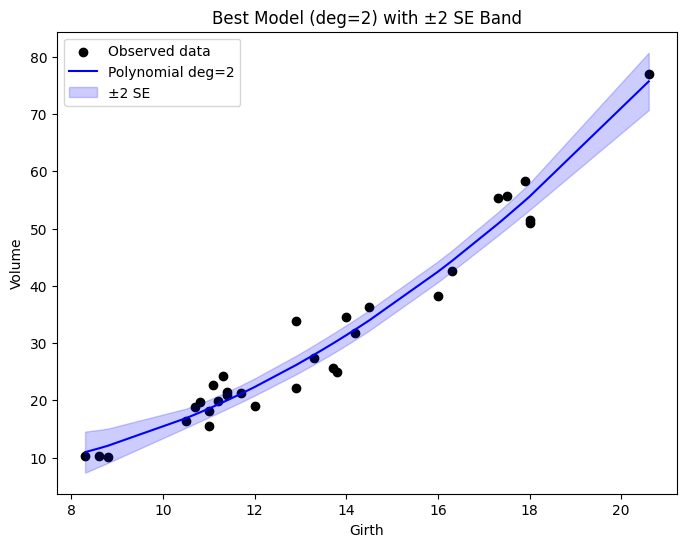

In [7]:
best_idx = np.argmax(adj_r2_list)
best_deg, best_poly, best_model = models[best_idx]

X_poly = best_poly.transform(X)
X_poly_sm = sm.add_constant(X_poly)

predictions = best_model.get_prediction(X_poly_sm)
pred_mean = predictions.predicted_mean
pred_ci = predictions.conf_int(alpha=0.05)
se = (pred_ci[:,1] - pred_ci[:,0]) / 4

plt.figure(figsize=(8,6))
plt.scatter(X, y, color='black', label='Observed data')
plt.plot(X, pred_mean, 'b-', label=f'Polynomial deg={best_deg}')
plt.fill_between(X.flatten(), pred_mean - 2*se, pred_mean + 2*se, color='blue', alpha=0.2, label='±2 SE')
plt.xlabel('Girth')
plt.ylabel('Volume')
plt.legend()
plt.title(f'Best Model (deg={best_deg}) with ±2 SE Band')
plt.show()

## Problem 2-2

In [8]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
X_poly_sm = sm.add_constant(X_poly)

y = (data["Volume"] > 30).astype(int) 

In [9]:
y

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    1
17    0
18    0
19    0
20    1
21    1
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    1
30    1
Name: Volume, dtype: int64

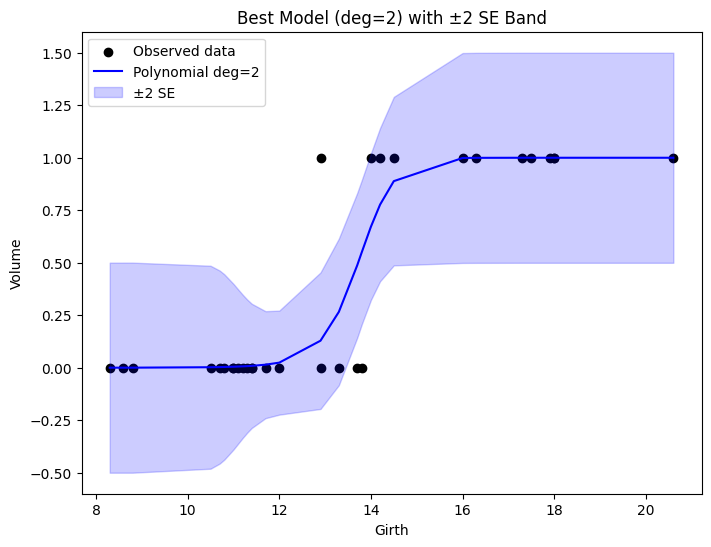

In [10]:
model = sm.Logit(y, X_poly_sm).fit(disp=False)
predictions = model.get_prediction(X_poly_sm)

pred = predictions.summary_frame()["predicted"]
pred_ci = predictions.summary_frame()[["ci_lower", "ci_upper"]].values
se = (pred_ci[:,1] - pred_ci[:,0]) / 4

plt.figure(figsize=(8,6))
plt.scatter(X, y, color='black', label='Observed data')
plt.plot(X, pred, 'b-', label=f'Polynomial deg={best_deg}')
plt.fill_between(X.flatten(), pred - 2*se, pred + 2*se, color='blue', alpha=0.2, label='±2 SE')
plt.xlabel('Girth')
plt.ylabel('Volume')
plt.legend()
plt.title(f'Best Model (deg={best_deg}) with ±2 SE Band')
plt.show()

## Problem 2-3

In [11]:
from patsy import dmatrix

In [12]:
X = data["Girth"].values.reshape(-1, 1)
y = data["Volume"].values

knots = [10, 14, 18]
transformed_x = dmatrix(
    "bs(Girth, knots=(10,14,18), degree=2, include_intercept=False)", 
    {"Girth": X}, 
    return_type='dataframe'
)

model = sm.OLS(y, transformed_x).fit()

In [13]:
transformed_x

,Intercept,"bs(Girth, knots=(10, 14, 18), degree=2, include_intercept=False)[0]","bs(Girth, knots=(10, 14, 18), degree=2, include_intercept=False)[1]","bs(Girth, knots=(10, 14, 18), degree=2, include_intercept=False)[2]","bs(Girth, knots=(10, 14, 18), degree=2, include_intercept=False)[3]","bs(Girth, knots=(10, 14, 18), degree=2, include_intercept=False)[4]"
0,1.0,0.000000,0.000000,0.000000,0.000000,0.0
1,1.0,0.312511,0.009288,0.000000,0.000000,0.0
2,1.0,0.475930,0.025800,0.000000,0.000000,0.0
3,1.0,0.537281,0.454907,0.007812,0.000000,0.0
4,1.0,0.477632,0.507056,0.015312,0.000000,0.0
5,1.0,0.449123,0.530877,0.020000,0.000000,0.0
6,1.0,0.394737,0.574013,0.031250,0.000000,0.0
7,1.0,0.394737,0.574013,0.031250,0.000000,0.0
8,1.0,0.368860,0.593328,0.037812,0.000000,0.0
9,1.0,0.343860,0.611140,0.045000,0.000000,0.0


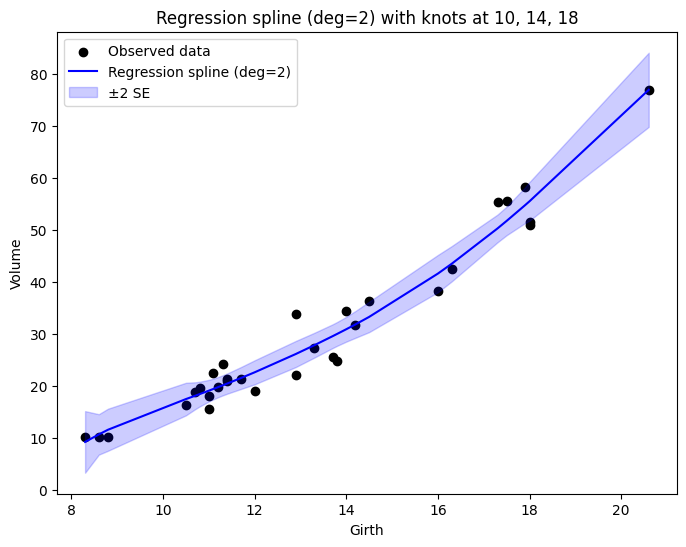

In [14]:
pred = model.get_prediction(transformed_x)
summary = pred.summary_frame()

plt.figure(figsize=(8,6))
plt.scatter(X, y, color='black', label='Observed data')
plt.plot(X, summary['mean'], 'b-', label='Regression spline (deg=2)')
plt.fill_between(X.flatten(), summary['mean_ci_lower'], summary['mean_ci_upper'], color='blue', alpha=0.2, label='±2 SE')
plt.xlabel('Girth')
plt.ylabel('Volume')
plt.legend()
plt.title('Regression spline (deg=2) with knots at 10, 14, 18')
plt.show()

## Problem 2-4

In [15]:
# we use the same transform 2-3
X = data["Girth"].values.reshape(-1, 1)
y = data["Volume"].values
N = transformed_x.values  
n, p = N.shape

In [16]:
# construct penalty
dx = np.diff(X.flatten()).mean()

d2N = np.gradient(np.gradient(N, axis=0), axis=0) / (dx ** 2)

Omega = (d2N.T @ d2N) * dx
Omega = (Omega + Omega.T) / 2  
Omega += np.eye(p) * 1e-8 

In [17]:
lambdas = np.logspace(-2, 2, 50)
print(lambdas[:5])     
print(lambdas[-5:])    

[0.01       0.01206793 0.01456348 0.01757511 0.02120951]
[ 47.14866363  56.89866029  68.6648845   82.86427729 100.        ]


In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_errors = []
for lam in lambdas:
    fold_errs = []
    for train_idx, val_idx in kf.split(N):
        N_train, N_val = N[train_idx], N[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Penalized least squares: beta = (NᵀN + λΩ)⁻¹ Nᵀy
        M = N_train.T @ N_train + lam * Omega
        n = N_train.T @ y_train
        beta = np.linalg.solve(M, n)
        y_pred = N_val @ beta
        fold_errs.append(mean_squared_error(y_val, y_pred))
    cv_errors.append(np.mean(fold_errs))

best_lambda = lambdas[np.argmin(cv_errors)]
print(f"Best lambda (CV): {best_lambda:.5f}")

Best lambda (CV): 0.01000


In [19]:
M_full = N.T @ N + best_lambda * Omega
n_full = N.T @ y
beta_hat = np.linalg.solve(M_full, n_full)


y_hat = N @ beta_hat
H = N @ np.linalg.solve(M_full, N.T)
edf = np.trace(H)
print(f"Effective degrees of freedom (trace(H)) = {edf:.3f}")

Effective degrees of freedom (trace(H)) = 5.875


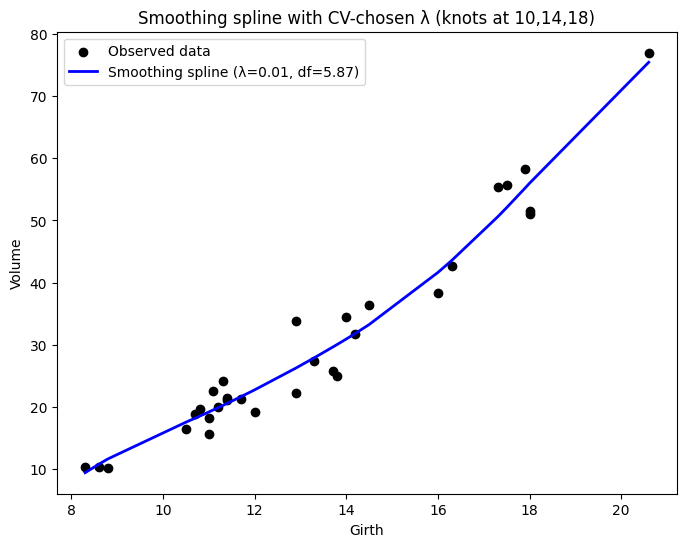

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(X, y, color='black', label='Observed data')
plt.plot(X, y_hat, 'b-', lw=2, label=f'Smoothing spline (λ={best_lambda:.2f}, df={edf:.2f})')
plt.xlabel('Girth')
plt.ylabel('Volume')
plt.legend()
plt.title('Smoothing spline with CV-chosen λ (knots at 10,14,18)')
plt.show()

## Problem 2-5

In [21]:
from pygam import LinearGAM, s

X = data[['Girth', 'Height']].values
y = data['Volume'].values

In [22]:
gam = LinearGAM(s(0, n_splines=4) + s(1, n_splines=5))
gam.gridsearch(X, y)  

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + s(1) + intercept, 
   tol=0.0001, verbose=False)

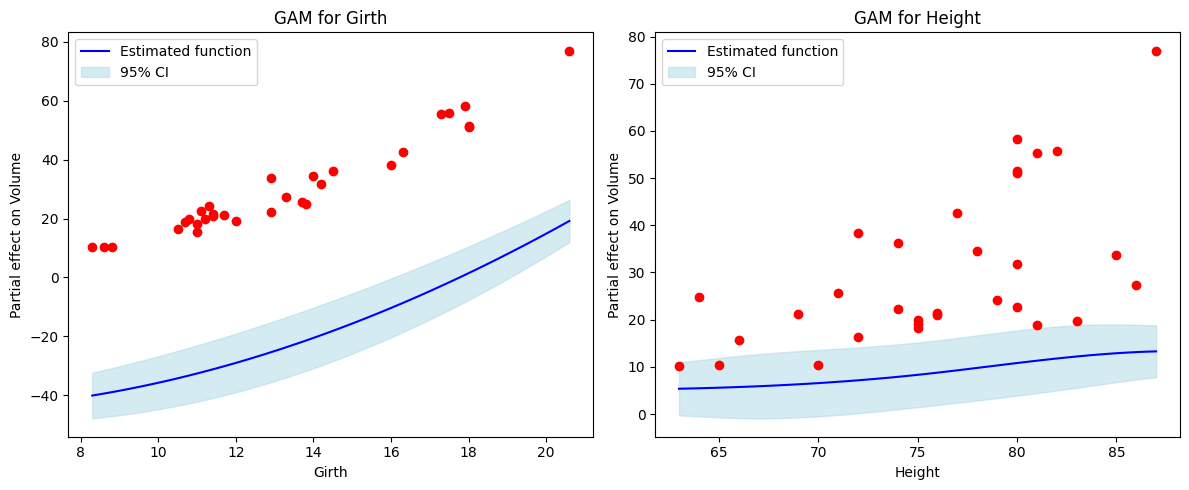

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

feature_names = ['Girth', 'Height']

for i in range(2):
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, width=0.95)
    
    axs[i].plot(XX[:, i], pdep, color='blue', label='Estimated function')
    axs[i].fill_between(XX[:, i], confi[:, 0], confi[:, 1], color='lightblue', alpha=0.5, label='95% CI')
    axs[i].scatter(X[:, i], y, color='red', zorder=10)
    axs[i].set_xlabel(feature_names[i])
    axs[i].set_ylabel('Partial effect on Volume')
    axs[i].legend()
    axs[i].set_title(f'GAM for {feature_names[i]}')

plt.tight_layout()
plt.show()

## Problem 3-1

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [25]:
data_train = pd.read_csv('/Users/mengchuishuo/Desktop/5054/HW3/audit_train.csv')

data_test = pd.read_csv('/Users/mengchuishuo/Desktop/5054/HW3/audit_test.csv')

data_train = data_train.dropna()

data_test = data_test.dropna()

In [26]:
X_train = data_train.drop(columns=["Risk"])
y_train = data_train["Risk"]

X_test = data_test.drop(columns=["Risk"])
y_test = data_test["Risk"]

### Fit classification tree on train

In [27]:
# # When multiple features have identical splitting criteria, 
# # the algorithm randomly selects one feature to split on.
# clf = DecisionTreeClassifier(random_state=21218480)

# clf.fit(X_train, y_train)

# # bug:ValueError: could not convert string to float: 'NUH'

# delete all string type data

X_train = X_train.select_dtypes(include=["number"])


X_test = X_test.select_dtypes(include=["number"])


In [28]:
clf = DecisionTreeClassifier(random_state=21218480)

clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=21218480)

### report the training error

In [29]:
y_train_pred = clf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
train_err = 1 - train_acc
print(f"Decision tree (full) training accuracy: {train_acc:.4f}, training error: {train_err:.4f}")

Decision tree (full) training accuracy: 0.9965, training error: 0.0035


### plot the tree

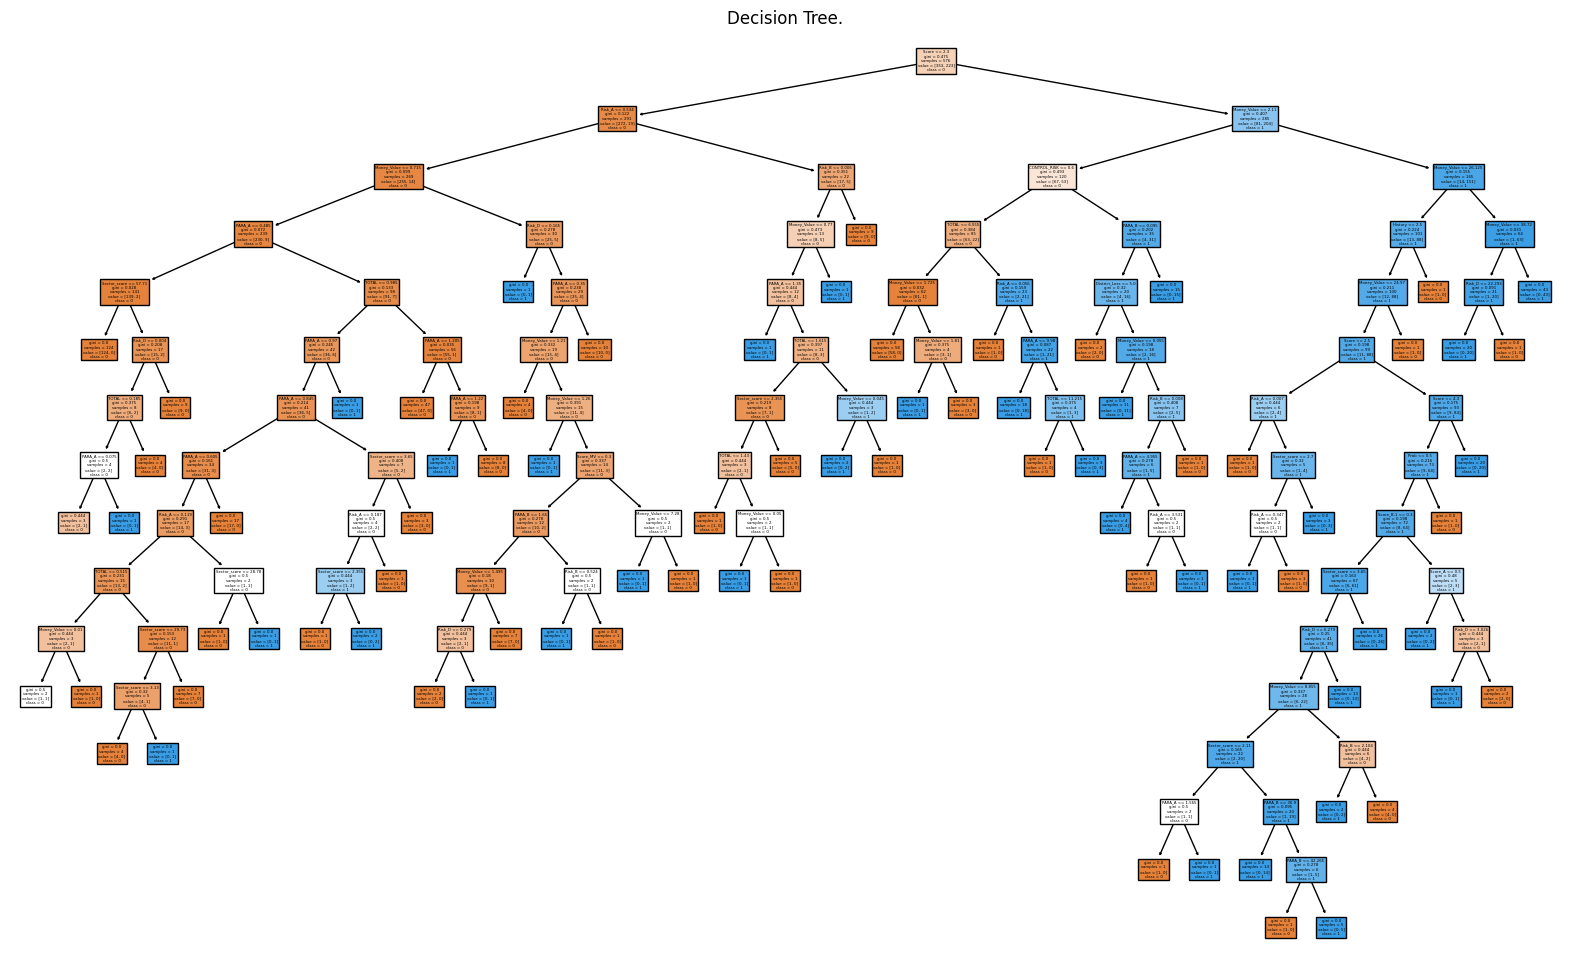

In [30]:
# plt.figure(figsize=(20,12))
# plot_tree(clf, feature_names=X_train.columns, class_names=["0","1"], filled=True, max_depth=4)  
# plt.title("Decision Tree (displaying first 4 levels).")
# plt.show()
# bug : The 'feature_names' parameter of plot_tree must be an instance of 'list' or None
plt.figure(figsize=(20,12))
plot_tree(clf, feature_names=list(X_train.columns), class_names=["0","1"], filled=True)  
plt.title("Decision Tree.")
plt.show()

### the confusion matrix on test dataset

In [31]:
y_test_pred = clf.predict(X_test)
cm_test = confusion_matrix(y_test, y_test_pred)
print("Confusion matrix on test (full tree):")
print(cm_test)
print(classification_report(y_test, y_test_pred))

Confusion matrix on test (full tree):
[[103   8]
 [ 12  76]]
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       111
           1       0.90      0.86      0.88        88

    accuracy                           0.90       199
   macro avg       0.90      0.90      0.90       199
weighted avg       0.90      0.90      0.90       199



## Problem 3-2 

In [32]:
path = clf.cost_complexity_pruning_path(X_train, y_train)

In [33]:
path

{'ccp_alphas': array([0.        , 0.0005787 , 0.00101273, 0.00113278, 0.00119712,
        0.00133035, 0.00138889, 0.00143659, 0.00144676, 0.00157828,
        0.00159668, 0.00163966, 0.0016572 , 0.00170811, 0.00170898,
        0.00185185, 0.00191139, 0.00201738, 0.00208333, 0.00235515,
        0.00237265, 0.00244992, 0.00302619, 0.00306437, 0.04034523,
        0.05408041, 0.21155046]),
 'impurities': array([0.00405093, 0.00462963, 0.00766782, 0.01219895, 0.01938169,
        0.03135487, 0.03413264, 0.039879  , 0.04277251, 0.04908565,
        0.05706902, 0.06034834, 0.06366274, 0.06707896, 0.07049693,
        0.07234878, 0.07999434, 0.08402911, 0.08819577, 0.10703696,
        0.11415491, 0.11905474, 0.12208093, 0.12820968, 0.20890013,
        0.26298055, 0.47453101])}

In [34]:
ccp_alphas = path.ccp_alphas
impurities = path.impurities
print("Number of alphas returned:", len(ccp_alphas))

# according to alphas, we can prune the decision tree by these alpha.

Number of alphas returned: 27


In [35]:
# For each alpha, train a tree and record training error via cross-validation
clfs = []
train_scores = []
cv_scores = []
for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state= 21218480, ccp_alpha = ccp_alpha)
    
    dt.fit(X_train, y_train)
    clfs.append(dt)
    train_scores.append(dt.score(X_train, y_train))
    
    cv = cross_val_score(dt, X_train, y_train, cv=5)
    cv_scores.append(cv.mean())

# Convert to error
train_errs = [1 - s for s in train_scores]
cv_errs = [1 - s for s in cv_scores]

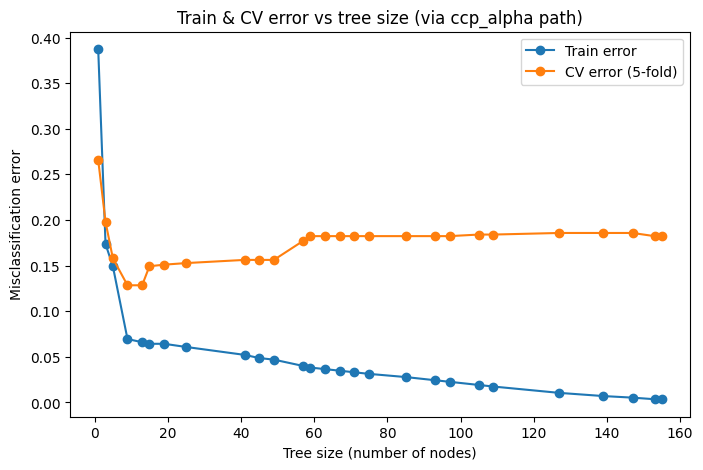

In [36]:
# Plot train error vs tree size
num_nodes = [est.tree_.node_count for est in clfs]

plt.figure(figsize=(8,5))
plt.plot(num_nodes, train_errs, marker='o', label='Train error')
plt.plot(num_nodes, cv_errs, marker='o', label='CV error (5-fold)')
plt.xlabel("Tree size (number of nodes)")
plt.ylabel("Misclassification error")
plt.title("Train & CV error vs tree size (via ccp_alpha path)")
plt.legend()
plt.show()

In [37]:
# find alpha corresponding to smallest CV error
best_idx = int(np.argmin(cv_errs))
best_alpha = ccp_alphas[best_idx]
best_tree = clfs[best_idx]
print(f"Best alpha by CV: {best_alpha:.6f}, tree nodes: {best_tree.tree_.node_count}, CV error: {cv_errs[best_idx]:.4f}")

Best alpha by CV: 0.003026, tree nodes: 13, CV error: 0.1284


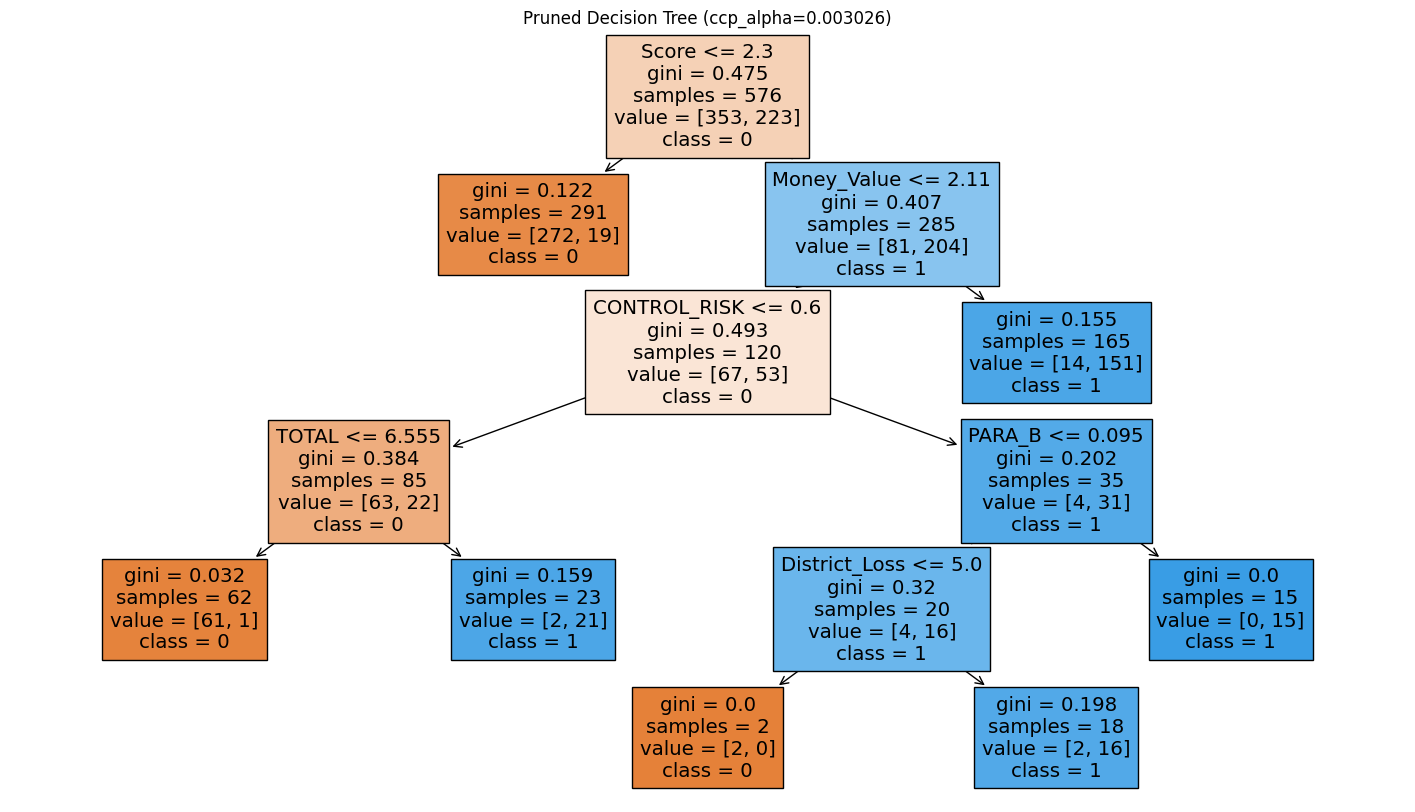

In [38]:
# plot the pruned tree
plt.figure(figsize=(18,10))
plot_tree(best_tree, feature_names=list(X_train.columns), class_names=["0","1"], filled=True)
plt.title(f"Pruned Decision Tree (ccp_alpha={best_alpha:.6f})")
plt.show()

In [39]:
# report the test error
y_test_pred_pruned = best_tree.predict(X_test)
cm_pruned = confusion_matrix(y_test, y_test_pred_pruned)
print("Confusion matrix on test (pruned tree):")
print(cm_pruned)
print(classification_report(y_test, y_test_pred_pruned))

Confusion matrix on test (pruned tree):
[[108   3]
 [  4  84]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       111
           1       0.97      0.95      0.96        88

    accuracy                           0.96       199
   macro avg       0.96      0.96      0.96       199
weighted avg       0.96      0.96      0.96       199



## Problem 3-3

In [40]:
# build a classifier to predict the risk where setting m=13 and ntree=25
# m means the number of features we choose to fit random forest

rf = RandomForestClassifier(n_estimators=25, max_features=13, random_state=21218480)
rf.fit(X_train, y_train)
y_train_pred_rf = rf.predict(X_train)
train_err_rf = 1 - accuracy_score(y_train, y_train_pred_rf)

# Report the training error
print(f"Random Forest (m=13, ntree=25) training error: {train_err_rf:.4f}")

Random Forest (m=13, ntree=25) training error: 0.0035


## Problem 3-4

In [41]:
m_values = [8, 12, 14, 16, 18]
train_errors = []


for m in m_values:
    rf = RandomForestClassifier(
        n_estimators=25,
        max_features=m,
        random_state=21218480
    )
    rf.fit(X_train, y_train)
    
    y_pred_train = rf.predict(X_train)
    
    train_error = 1 - accuracy_score(y_train, y_pred_train)
    
    train_errors.append(train_error)

In [42]:
for m, train_err in zip(m_values, train_errors):
    print(f"m={m} -> train error: {train_err:.4f}")

m=8 -> train error: 0.0035
m=12 -> train error: 0.0035
m=14 -> train error: 0.0035
m=16 -> train error: 0.0035
m=18 -> train error: 0.0035


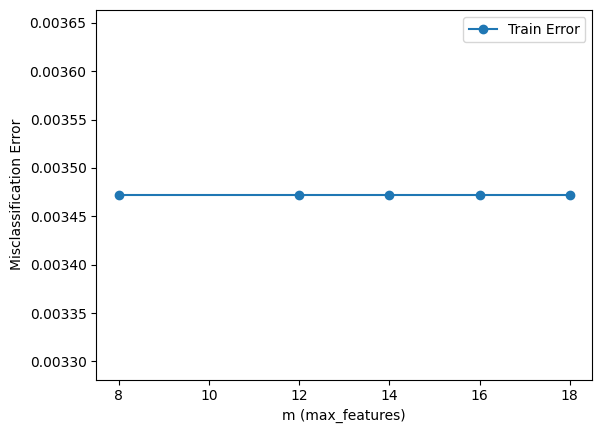

In [43]:
plt.plot(m_values, train_errors, label="Train Error", marker="o")
plt.xlabel("m (max_features)")
plt.ylabel("Misclassification Error")
plt.legend()
plt.show()

### we should choose m=8.

In [44]:
# Test its performance on the test dataset.
best_rf_model = RandomForestClassifier(
    n_estimators=25,
    max_features=8,   
    random_state=21218480
)

best_rf_model.fit(X_train, y_train)

y_test_rf = best_rf_model.predict(X_test)
cm_rf = confusion_matrix(y_test, y_test_rf)
print("Confusion matrix on test (best RF):")
print(cm_rf)
print(classification_report(y_test, y_test_rf))

Confusion matrix on test (best RF):
[[107   4]
 [  4  84]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       111
           1       0.95      0.95      0.95        88

    accuracy                           0.96       199
   macro avg       0.96      0.96      0.96       199
weighted avg       0.96      0.96      0.96       199



## Problem 3-5

* Pruning and Random Forest both improve generalization compared to the full tree.
* Both the pruned decision tree and random forest achieve about 96% test accuracy, showing that ensemble methods and regularization achieve similar, stable results.

## Problem 4

In [45]:
hitters_train = pd.read_csv('/Users/mengchuishuo/Desktop/5054/HW3/Hitters_train.csv')

hitters_test = pd.read_csv('/Users/mengchuishuo/Desktop/5054/HW3/Hitters_test.csv')

hitters_train = hitters_train.dropna()

hitters_test = hitters_test.dropna()

In [46]:
features = ['Years', 'Hits', 'RBI', 'Walks', 'PutOuts', 'Runs']
X_train = hitters_train[features].values
y_train = hitters_train['Salary'].values

X_test = hitters_test[features].values
y_test = hitters_test['Salary'].values

In [47]:
class TreeNode:
    def __init__(self, prediction, depth=0):
        self.prediction = prediction
        self.feature_index = None
        self.threshold = None
        self.left = None
        self.right = None
        self.depth = depth

In [48]:
class RegressionTree:
    def __init__(self, max_leaves=10, vgain=1e-3):
        self.max_leaves = max_leaves
        self.vgain = vgain
        self.root = None
        self.leaves = 0

    def _median_loss(self, y):
        """Return median and absolute loss for a node."""
        if len(y) == 0:
            return 0, 0
        median = np.median(y)
        loss = np.sum(np.abs(y - median))
        return median, loss

    def _best_split(self, X, y):
        """Find the split that minimizes absolute loss."""
        n, d = X.shape
        base_median, base_loss = self._median_loss(y)
        best_gain, best_feat, best_thresh = 0, None, None

        for j in range(d):
            values = np.unique(X[:, j])
            for t in values:
                left_mask = X[:, j] <= t
                right_mask = ~left_mask
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                _, left_loss = self._median_loss(y[left_mask])
                _, right_loss = self._median_loss(y[right_mask])
                gain = base_loss - (left_loss + right_loss)
                if gain > best_gain:
                    best_gain = gain
                    best_feat = j
                    best_thresh = t
        return best_feat, best_thresh, best_gain

    def _fit_node(self, X, y, depth=0):
        median, loss = self._median_loss(y)
        node = TreeNode(prediction=median, depth=depth)

        # stopping conditions
        if self.leaves >= self.max_leaves:
            return node
        feat, thresh, gain = self._best_split(X, y)
        if feat is None or gain < self.vgain:
            return node

        # split data
        left_mask = X[:, feat] <= thresh
        right_mask = ~left_mask
        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return node

        node.feature_index = feat
        node.threshold = thresh
        self.leaves += 1
        node.left = self._fit_node(X[left_mask], y[left_mask], depth + 1)
        node.right = self._fit_node(X[right_mask], y[right_mask], depth + 1)
        return node

    def fit(self, X, y):
        self.leaves = 1
        self.root = self._fit_node(X, y)

    def _predict_one(self, x, node):
        if node.feature_index is None:
            return node.prediction
        if x[node.feature_index] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])

In [49]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

leaves_list = [3, 5, 8, 10, 12, 14, 16, 18, 20]
vgain_list = [0.001, 0.005, 0.01, 0.1]

results = []

kf = KFold(n_splits=5, shuffle=True, random_state=21218480)  # 5-fold CV

for leaves in leaves_list:
    for vgain in vgain_list:
        cv_mae = []
        for train_idx, val_idx in kf.split(X_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            model = RegressionTree(max_leaves=leaves, vgain=vgain)
            model.fit(X_tr, y_tr)
            y_val_pred = model.predict(X_val)
            mae = mean_absolute_error(y_val, y_val_pred)
            cv_mae.append(mae)
        
        mean_cv_mae = np.mean(cv_mae)
        results.append((leaves, vgain, mean_cv_mae))


results = sorted(results, key=lambda x: x[2])

print("=== Cross-Validation Results (sorted by CV MAE) ===")
for leaves, vgain, mae in results[:5]:
    print(f"max_leaves={leaves}, vgain={vgain}, mean CV MAE={mae:.4f}")


=== Cross-Validation Results (sorted by CV MAE) ===
max_leaves=20, vgain=0.01, mean CV MAE=0.4733
max_leaves=18, vgain=0.001, mean CV MAE=0.4733
max_leaves=18, vgain=0.005, mean CV MAE=0.4733
max_leaves=18, vgain=0.01, mean CV MAE=0.4733
max_leaves=20, vgain=0.001, mean CV MAE=0.4734


In [50]:
best_leaves, best_vgain, best_mae = results[0]
print("\nBest parameter combination based on CV:")
print(f"max_leaves={best_leaves}, vgain={best_vgain}, mean CV MAE={best_mae:.4f}")


best_model = RegressionTree(max_leaves=best_leaves, vgain=best_vgain)
best_model.fit(X_train, y_train)
y_test_pred = best_model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\nFinal test MAE (best CV model): {test_mae:.4f}")



Best parameter combination based on CV:
max_leaves=20, vgain=0.01, mean CV MAE=0.4733

Final test MAE (best CV model): 0.4530
